In [3]:
import os

# 1. Define the relative paths from your "Code" directory
relative_paths = {
    "Cardboard": r"..\Data\Trashnet\Sam3 cardboard consolidated output\largest_bounding_box",
    "Glass": r"..\Data\Trashnet\Sam3 glass consolidated output\largest_bounding_box",
    "Metal": r"..\Data\Trashnet\Sam3 metal consolidated output\largest_bounding_box",
    "Paper": r"..\Data\Trashnet\Sam3 paper consolidated output\largest_bounding_box",
    "Plastic": r"..\Data\Trashnet\Sam3 plastic consolidated output\largest_bounding_box",
    "Trash": r"..\Data\Trashnet\Sam3 trash consolidated output\largest_bounding_box",
    "Bluebins": r"..\Data\Sam3 Bluebins consolidated output\largest_bounding_box"
}

file_counts = {}

print("File Counts Per Folder:")
print("-" * 30)

# 2. Loop through each folder to count the files
for category, path in relative_paths.items():
    if os.path.exists(path):
        # Count only files to avoid accidental sub-directory counts
        count = len([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])
        file_counts[category] = count
        print(f"{category:<10}: {count} files")
    else:
        print(f"{category:<10}: PATH NOT FOUND ({path})")
        # Assign infinity so a missing folder doesn't accidentally set your sample_size to 0
        file_counts[category] = float('inf') 

print("-" * 30)

# 3. Extract the smallest number and call it sample_size
if file_counts:
    sample_size = min(file_counts.values())
    if sample_size == float('inf'):
        print("\nError: None of the paths were found. Please check your working directory.")
        sample_size = 0
    else:
        print(f"Smallest number of files (sample_size) = {sample_size}")

File Counts Per Folder:
------------------------------
Cardboard : 373 files
Glass     : 266 files
Metal     : 293 files
Paper     : 240 files
Plastic   : 426 files
Trash     : 101 files
Bluebins  : 259 files
------------------------------
Smallest number of files (sample_size) = 101


In [4]:
import os
import random
import shutil
import glob

# Ensure reproducibility so you get the same random selection if you re-run
random.seed(42)

# 1. Define output directory for the balanced dataset
output_dir = r"..\Data\Balanced_YOLO_Dataset"
output_images = os.path.join(output_dir, "images")
output_labels = os.path.join(output_dir, "labels")

os.makedirs(output_images, exist_ok=True)
os.makedirs(output_labels, exist_ok=True)

# 2. Map categories to their respective image and label relative paths
dataset_paths = {
    "Cardboard": {
        "images": r"..\Data\Trashnet\cardboard",
        "labels": r"..\Data\Trashnet\Sam3 cardboard consolidated output\largest_bounding_box"
    },
    "Glass": {
        "images": r"..\Data\Trashnet\glass",
        "labels": r"..\Data\Trashnet\Sam3 glass consolidated output\largest_bounding_box"
    },
    "Metal": {
        "images": r"..\Data\Trashnet\metal",
        "labels": r"..\Data\Trashnet\Sam3 metal consolidated output\largest_bounding_box"
    },
    "Paper": {
        "images": r"..\Data\Trashnet\paper",
        "labels": r"..\Data\Trashnet\Sam3 paper consolidated output\largest_bounding_box"
    },
    "Plastic": {
        "images": r"..\Data\Trashnet\plastic",
        "labels": r"..\Data\Trashnet\Sam3 plastic consolidated output\largest_bounding_box"
    },
    "Trash": {
        "images": r"..\Data\Trashnet\trash",
        "labels": r"..\Data\Trashnet\Sam3 trash consolidated output\largest_bounding_box"
    },
    "Bluebins": {
        "images": r"..\Data\Bluebins",
        "labels": r"..\Data\Sam3 Bluebins consolidated output\largest_bounding_box"
    }
}

print(f"Creating balanced dataset with {sample_size} samples per class...")
print("-" * 50)

# 3. Loop through, match files, sample, and copy
for category, paths in dataset_paths.items():
    img_dir = paths["images"]
    lbl_dir = paths["labels"]
    
    if not os.path.exists(img_dir) or not os.path.exists(lbl_dir):
        print(f"Skipping {category}: Directories not found.")
        continue

    # Get all .txt label files
    txt_files = [f for f in os.listdir(lbl_dir) if f.endswith('.txt')]
    
    valid_pairs = []
    
    # Match labels to images
    for txt_file in txt_files:
        base_name = os.path.splitext(txt_file)[0]
        # Search for any image with the same base name in the image directory
        matching_images = glob.glob(os.path.join(img_dir, f"{base_name}.*"))
        
        # Filter out non-image files
        matching_images = [img for img in matching_images if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if matching_images:
            valid_pairs.append((matching_images[0], os.path.join(lbl_dir, txt_file)))
            
    # Sample logic
    if len(valid_pairs) < sample_size:
        print(f"⚠️ Warning: {category} only has {len(valid_pairs)} matching image/label pairs. Expected {sample_size}.")
        sampled_pairs = valid_pairs 
    else:
        sampled_pairs = random.sample(valid_pairs, sample_size)
        
    # Copy files directly with their original names
    for img_path, txt_path in sampled_pairs:
        orig_img_name = os.path.basename(img_path)
        orig_txt_name = os.path.basename(txt_path)
        
        shutil.copy(img_path, os.path.join(output_images, orig_img_name))
        shutil.copy(txt_path, os.path.join(output_labels, orig_txt_name))
        
    print(f"✔ {category:<10}: Copied {len(sampled_pairs)} image/label pairs.")

print("-" * 50)
print(f"Done! Balanced dataset saved to: {output_dir}")

Creating balanced dataset with 101 samples per class...
--------------------------------------------------
✔ Cardboard : Copied 101 image/label pairs.
✔ Glass     : Copied 101 image/label pairs.
✔ Metal     : Copied 101 image/label pairs.
✔ Paper     : Copied 101 image/label pairs.
✔ Plastic   : Copied 101 image/label pairs.
✔ Trash     : Copied 101 image/label pairs.
✔ Bluebins  : Copied 101 image/label pairs.
--------------------------------------------------
Done! Balanced dataset saved to: ..\Data\Balanced_YOLO_Dataset


In [5]:
import os

# 1. Define your exact category mapping (fixed the missing quote)
category_mapping = {
    "Bluebins": 0, 
    "Cardboard": 1, 
    "Glass": 2, 
    "Metal": 3, 
    "Paper": 4, 
    "Plastic": 5, 
    "Trash": 6
}

# 2. Define the paths to your label folders
label_paths = {
    "Cardboard": r"..\Data\Trashnet\Sam3 cardboard consolidated output\largest_bounding_box",
    "Glass": r"..\Data\Trashnet\Sam3 glass consolidated output\largest_bounding_box",
    "Metal": r"..\Data\Trashnet\Sam3 metal consolidated output\largest_bounding_box",
    "Paper": r"..\Data\Trashnet\Sam3 paper consolidated output\largest_bounding_box",
    "Plastic": r"..\Data\Trashnet\Sam3 plastic consolidated output\largest_bounding_box",
    "Trash": r"..\Data\Trashnet\Sam3 trash consolidated output\largest_bounding_box",
    "Bluebins": r"..\Data\Sam3 Bluebins consolidated output\largest_bounding_box"
}

print("Checking YOLO label class IDs...")
print("-" * 50)

total_errors = 0

# 3. Loop through each category and verify the contents of the text files
for category, expected_id in category_mapping.items():
    lbl_dir = label_paths.get(category)
    
    if not lbl_dir or not os.path.exists(lbl_dir):
        print(f"Skipping {category}: Directory not found.")
        continue

    txt_files = [f for f in os.listdir(lbl_dir) if f.endswith('.txt')]
    
    files_checked = 0
    errors_in_category = 0
    
    for txt_file in txt_files:
        file_path = os.path.join(lbl_dir, txt_file)
        files_checked += 1
        
        with open(file_path, 'r') as file:
            lines = file.readlines()
            
            for line_num, line in enumerate(lines, 1):
                line = line.strip()
                if not line:
                    continue # Skip empty lines
                
                # YOLO format: <class> <x_center> <y_center> <width> <height>
                parts = line.split()
                actual_id = parts[0]
                
                if actual_id != str(expected_id):
                    print(f"❌ Mismatch in {category} -> File: {txt_file}, Line: {line_num}")
                    print(f"   Expected ID: {expected_id}, Found ID: {actual_id}")
                    errors_in_category += 1
                    total_errors += 1
                    
    if errors_in_category == 0:
        print(f"✔ {category:<10}: All {files_checked} files have the correct class ID ({expected_id}).")

print("-" * 50)
if total_errors == 0:
    print("Perfect! All labels match your category mapping.")
else:
    print(f"Found {total_errors} lines with incorrect class IDs. You will need to fix these before training.")

Checking YOLO label class IDs...
--------------------------------------------------
✔ Bluebins  : All 259 files have the correct class ID (0).
✔ Cardboard : All 373 files have the correct class ID (1).
✔ Glass     : All 266 files have the correct class ID (2).
✔ Metal     : All 293 files have the correct class ID (3).
✔ Paper     : All 240 files have the correct class ID (4).
✔ Plastic   : All 426 files have the correct class ID (5).
✔ Trash     : All 101 files have the correct class ID (6).
--------------------------------------------------
Perfect! All labels match your category mapping.


In [1]:
import os
import random
import shutil

# Ensure reproducibility
random.seed(42)

# Define paths
source_dir = r"..\Data\Balanced_YOLO_Dataset"
source_images = os.path.join(source_dir, "images")
source_labels = os.path.join(source_dir, "labels")

output_dir = r"..\Data\YOLO11_Ready_Dataset"
folders = ["train/images", "train/labels", "val/images", "val/labels"]

# Create the YOLO directory structure
for folder in folders:
    os.makedirs(os.path.join(output_dir, folder), exist_ok=True)

# Get and shuffle files
all_images = [f for f in os.listdir(source_images) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
random.shuffle(all_images)

# Calculate 80/20 split index
split_idx = int(len(all_images) * 0.8)
train_files = all_images[:split_idx]
val_files = all_images[split_idx:]

print(f"Total images: {len(all_images)} | Training: {len(train_files)} | Validation: {len(val_files)}")
print("-" * 50)

# Helper function to copy files into their respective splits
def distribute_data(file_list, split_type):
    for img_name in file_list:
        base_name = os.path.splitext(img_name)[0]
        txt_name = f"{base_name}.txt"
        
        src_img = os.path.join(source_images, img_name)
        src_txt = os.path.join(source_labels, txt_name)
        
        dst_img = os.path.join(output_dir, split_type, "images", img_name)
        dst_txt = os.path.join(output_dir, split_type, "labels", txt_name)
        
        shutil.copy(src_img, dst_img)
        if os.path.exists(src_txt):
            shutil.copy(src_txt, dst_txt)

# Execute the split
distribute_data(train_files, "train")
distribute_data(val_files, "val")
print("✔ Images and labels copied to train/val folders.")

# Generate data.yaml using your exact category mapping
yaml_path = os.path.join(output_dir, "data.yaml")
yaml_content = """train: train/images
val: val/images

nc: 7
names: ['Bluebins', 'Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic', 'Trash']
"""

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(f"✔ data.yaml generated at: {yaml_path}")
print("-" * 50)
print("Dataset split complete and ready for YOLO26 training!")

Total images: 707 | Training: 565 | Validation: 142
--------------------------------------------------
✔ Images and labels copied to train/val folders.
✔ data.yaml generated at: ..\Data\YOLO11_Ready_Dataset\data.yaml
--------------------------------------------------
Dataset split complete and ready for YOLO26 training!


In [2]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

# Start training with advanced configurations
results = model.train(
    # --- Core Settings ---
    data=r"..\Data\YOLO11_Ready_Dataset\data.yaml",
    epochs=100,             # Increased epochs since we have early stopping
    imgsz=640,              # Image size
    batch=16,               # Batch size (drop to 8 if you run out of GPU memory)
    device=0,               # Explicitly forces the use of your primary GPU
    
    # --- Optimization ---
    optimizer='Adam',       # Uses the Adam optimizer as requested (AdamW is also great)
    lr0=0.001,              # Initial learning rate (Adam generally performs well at 1e-3)
    patience=20,            # Early stopping: halts training if no improvement for 20 epochs
    weight_decay=0.0005,    # Penalizes large weights to prevent overfitting
    cos_lr=True,            # Gradually decreases learning rate following a cosine curve
    workers=8,              # CPU threads for data loading (decrease if your CPU bottlenecks)
    
    # # --- Data Augmentation ---
    # mosaic=1.0,             # 100% probability of combining 4 images into 1
    # mixup=0.1,              # 10% probability of blending two images together
    # degrees=10.0,           # Randomly rotates images by up to +/- 10 degrees
    # translate=0.1,          # Randomly translates (shifts) images by 10%
    # scale=0.5,              # Randomly scales images by +/- 50%
    # fliplr=0.5,             # 50% chance to flip images left-to-right
    # hsv_h=0.015,            # Adjusts hue slightly to handle different lighting
    # hsv_s=0.7,              # Adjusts saturation to handle different lighting
    # hsv_v=0.4               # Adjusts exposure/value
)

New https://pypi.org/project/ultralytics/8.4.21 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.239  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=..\Data\YOLO11_Ready_Dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2,


image 1/1 C:\Users\shenl\OneDrive\Documents\NUS\MS2\DSA5106-Deep Learning - Foundations and Tecniques\Project\Data\leftImg8bit_trainvaltest\leftImg8bit\train\aachen\aachen_000031_000019_leftImg8bit.png: 320x640 7 persons, 2 bicycles, 2 traffic lights, 75.5ms
Speed: 4.9ms preprocess, 75.5ms inference, 12.5ms postprocess per image at shape (1, 3, 320, 640)


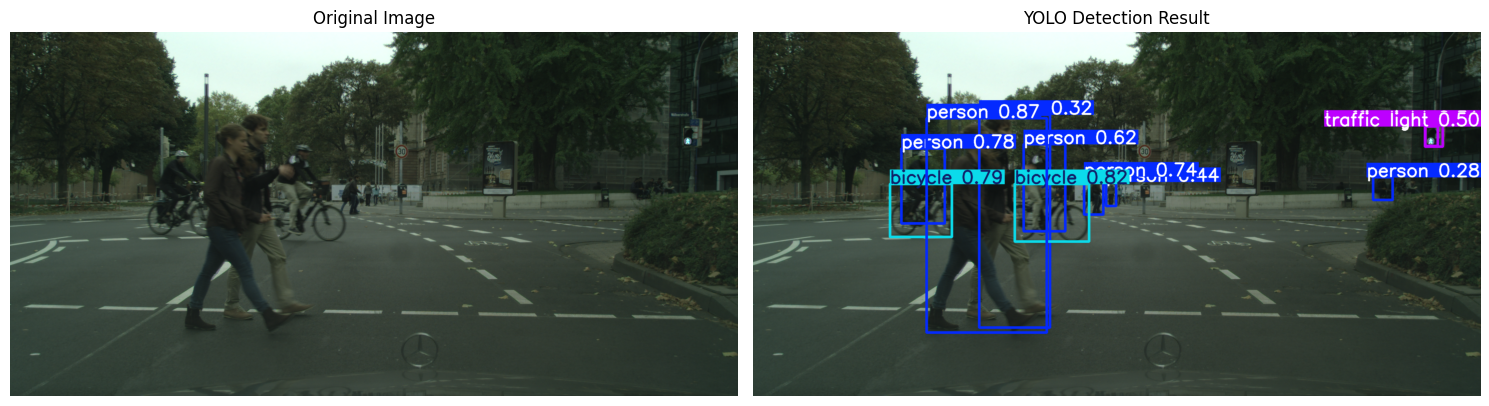

In [1]:
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image
import cv2

model_path = r"C:\Users\shenl\OneDrive\Documents\NUS\MS2\CS5224-Cloud Computing\Project\Machine Learning\Code\yolo11s.pt"
model = YOLO(model_path)

image_path = r"C:\Users\shenl\OneDrive\Documents\NUS\MS2\DSA5106-Deep Learning - Foundations and Tecniques\Project\Data\leftImg8bit_trainvaltest\leftImg8bit\train\aachen\aachen_000031_000019_leftImg8bit.png"  # Update this to your image file
results = model.predict(image_path)

original_image = Image.open(image_path)
annotated_image = results[0].plot()
annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(15, 7))

ax[0].imshow(original_image)
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(annotated_image_rgb)
ax[1].set_title("YOLO Detection Result")
ax[1].axis('off')

plt.tight_layout()
plt.show()


image 1/1 C:\Users\shenl\OneDrive\Documents\NUS\MS2\CS5224-Cloud Computing\Project\Machine Learning\Data\OOS images\rice-media-recycling-cover.jpg: 448x640 1 Bluebins, 47.5ms
Speed: 6.1ms preprocess, 47.5ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)


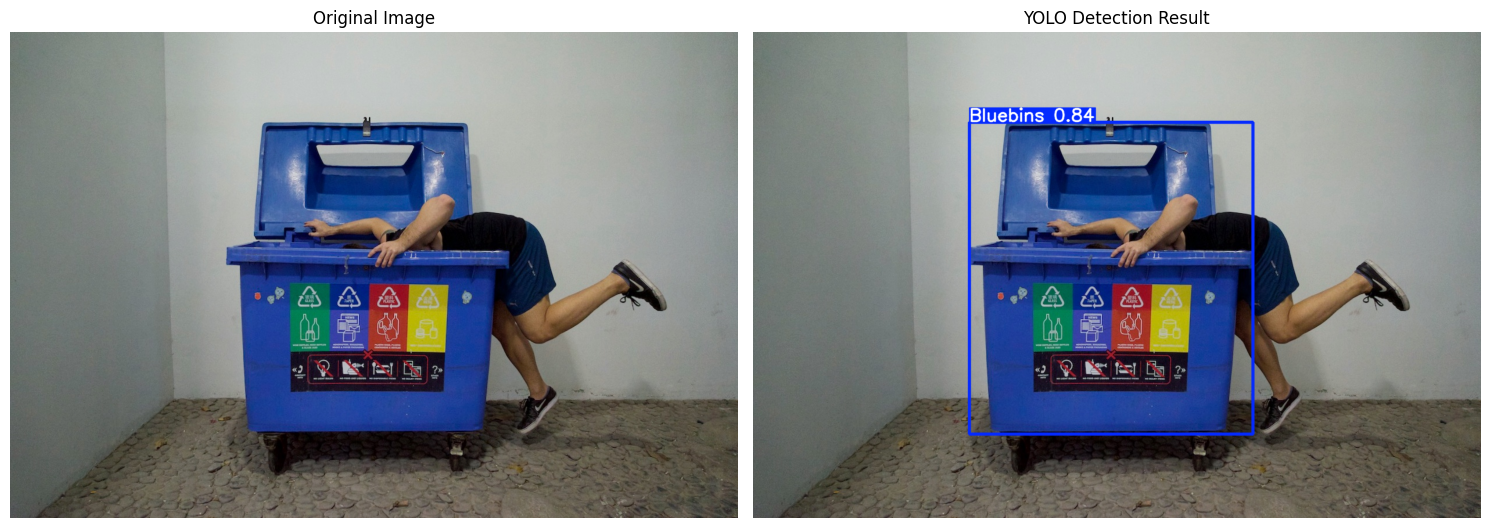

In [28]:
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image
import cv2

model_path = r"C:\Users\shenl\OneDrive\Documents\NUS\MS2\CS5224-Cloud Computing\Project\Machine Learning\Code\runs\detect\train2\weights\last.pt"
model = YOLO(model_path)

image_path = r"C:\Users\shenl\OneDrive\Documents\NUS\MS2\CS5224-Cloud Computing\Project\Machine Learning\Data\OOS images\rice-media-recycling-cover.jpg"  # Update this to your image file
results = model.predict(image_path)

original_image = Image.open(image_path)
annotated_image = results[0].plot()
annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(15, 7))

ax[0].imshow(original_image)
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(annotated_image_rgb)
ax[1].set_title("YOLO Detection Result")
ax[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import cv2

# --- Configuration ---
# Set your desired confidence threshold here
CONF_THRESHOLD = 0.25 

model_path = r"C:\Users\shenl\OneDrive\Documents\NUS\MS2\CS5224-Cloud Computing\Project\Machine Learning\Code\runs\detect\train2\weights\best.pt"
input_dir = Path(r"C:\Users\shenl\OneDrive\Documents\NUS\MS2\CS5224-Cloud Computing\Project\Machine Learning\Data\OOS images")
output_dir = Path(r"C:\Users\shenl\OneDrive\Documents\NUS\MS2\CS5224-Cloud Computing\Project\Machine Learning\Data\OOS overlay")

# Create the output directory if it doesn't exist
output_dir.mkdir(parents=True, exist_ok=True)

# Load model
model = YOLO(model_path)

# Process all images
image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp']
image_files = [f for ext in image_extensions for f in input_dir.glob(ext)]

print(f"Found {len(image_files)} images. Starting inference...")

for img_path in image_files:
    # Run prediction
    results = model.predict(source=str(img_path), conf=CONF_THRESHOLD, verbose=False)
    
    # results[0] contains all detections for this specific image
    res = results[0]
    
    # This plots ALL bounding boxes and labels found in 'res'
    annotated_img = res.plot(
        conf=True,        # Show confidence scores
        line_width=4,     # Adjust line thickness if it's too crowded
        font_size=4,    # Adjust font size for labels
        labels=True       # Ensure class labels are shown
    )
    
    save_path = output_dir / f"overlay_{img_path.name}"
    cv2.imwrite(str(save_path), annotated_img)
    
    # Debug print: See exactly how many items were detected in this image
    print(f"Saved: {save_path.name} | Detected: {len(res.boxes)} objects")
print("Processing complete.")

Found 6 images. Starting inference...
Saved: overlay_71QICIcKQ+L._AC_UF894,1000_QL80_.jpg | Detected: 0 objects
Saved: overlay_istockphoto-1341903801-612x612.jpg | Detected: 1 objects
Saved: overlay_metal62.jpg | Detected: 1 objects
Saved: overlay_Recycle___NW.jpg | Detected: 1 objects
Saved: overlay_rice-media-recycling-cover.jpg | Detected: 2 objects
Saved: overlay_coca_cola.png | Detected: 1 objects
Processing complete.


In [22]:
model = YOLO(model_path)
print(model.names)

{0: 'Bluebins', 1: 'Cardboard', 2: 'Glass', 3: 'Metal', 4: 'Paper', 5: 'Plastic', 6: 'Trash'}
